# Wildfire → Solar · M1 — Catalog (per-asset hazard profile)

**Peril:** Wildfire · **Layer:** M1 (catalog) · assets: Hayhurst (TX, low-fire) + Matrix (ID, high-fire).

M0 met the raw hazard; **M1 turns it into the typed handoff the loss engine consumes** — per asset, a
**frequency (λ)** and a **conditional severity distribution** on fire-line intensity (kW/m), plus a manifest
declaring the catalog's choices. Built for both assets.

> Plan: [`docs/plans/wildfire/m1_catalog.md`](../../../docs/plans/wildfire/m1_catalog.md) ·
> Decisions: [DD-W4](../../../docs/plans/wildfire/decisions.md) (FSim spine) · **DD-W7** (frequency, below) ·
> Data dictionary: [`discussion/wildfire/02`](../../../docs/extra/discussion/wildfire/02_fsim_wrc_data_dictionary.md).

## 1 · The structural twist — why wildfire M1 ≠ hail M1 (the reason we work in notebooks)

Hail M1 *extracted* discrete events (hail-day footprint polygons) from raw radar and *fit* a regional rate
`λ_collection` from a short, noisy record (the whole NegBin / dispersion saga). **Wildfire does none of that
— because FSim already ran the event simulation.** FSim Monte-Carlos ≥20,000 fire seasons and pre-integrates
them into two per-pixel layers: **BP** (annual burn probability — the "how often") and the **FLP1-6
histogram** (conditional flame-length given a fire — the "how severe").

| | Hail (areal hit-or-miss) | **Wildfire (site-conditioned)** |
|---|---|---|
| Events | extract hail-day footprints from MRMS | **FSim pre-integrated → no event extraction** |
| Frequency | **fit** `λ_collection` from a short record (NegBin) | **BP *is* the annual rate** — no fit, no dispersion to estimate |
| Catalog grain | one **regional** event set, shared across assets | **per-asset** profile (the field is site-specific) |
| Severity | conditional-on-hit size distribution | **FLP1-6 histogram → kW/m** |

**This is doctrine, not just our read.** The Hazard Data Reference says it for wildfire: *"no track→swath
step — the simulator outputs the footprint statistics directly."* And the methodology says for
site-conditioned perils *"there is no 'miss', so `λ_collection × spatial_factor` does not apply; the
relevant-event rate comes from the site intensity process directly."*

So **M1 here assembles the per-asset hazard profile (BP→λ, FLP→severity) and declares the process** — ready
for the *same* compound engine the hail M4 uses. *(This areal-vs-site-conditioned contrast is a
`learning_logs` candidate, #09.)*

## 2 · The five catalog choices (declared in the manifest, mirroring hail M1)

1. **Ontology** — a **per-asset hazard profile** `{λ, FLP1-6 conditional flame-length histogram}` over the
   footprint. *(A20's fire-perimeter polygon is the conceptual event identity; V1 uses FSim's pre-integrated
   BP+FLP, **not** discrete perimeters — a documented simplification.)*
2. **Backbone / spine** — **FSim FLP1-6 + BP** (`RDS-2016-0034-3`, 270 m) from M0 candidate 02; WRC 30 m
   cross-check ([DD-W4](../../../docs/plans/wildfire/decisions.md)).
3. **Interface object** — per-asset `{lambda_per_yr, fano_factor, severity_kwm_distribution, tiv, footprint}`
   — the exact keys the shared engine reads.
4. **Frequency process** — **Poisson(λ)**, `λ = −ln(1−BP)` (≈ BP); a *site-conditioned annual occurrence
   draw*, not areal thinning; `fano = 1` (**DD-W7**, below).
5. **Magnitude metric** — **fire-line intensity (kW/m)**, via Byram from the FLP flame-length classes.

In [1]:
from __future__ import annotations
import json, math
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.features import rasterize
from shapely import wkb
from shapely.geometry import Point
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "wildfire"
RAW_BASE = DATA_DIR / "raw"

# FIL flame-length classes (verified, data-dictionary §3) → Byram fire-line intensity (kW/m) at class midpoints
FIL_FT = ["<2", "2–4", "4–6", "6–8", "8–12", "12+"]
FIL_MID_FT = np.array([1.0, 3.0, 5.0, 7.0, 10.0, 15.0])      # FIL6 "12+" is open-ended → 15 ft is representative (coarse, flagged)


def byram_kwm(fl_ft: float) -> float:
    """Flame length (ft) → Byram fire-line intensity (kW/m). FL_m = 0.0775·I^0.46  ⇒  I = (FL_m/0.0775)^(1/0.46)."""
    if fl_ft <= 0:
        return 0.0
    return (fl_ft * 0.3048 / 0.0775) ** (1 / 0.46)


FIL_KWM = np.array([byram_kwm(ft) for ft in FIL_MID_FT])
print("FIL class → representative fire-line intensity (Byram):")
for lab, ft, kwm in zip(FIL_FT, FIL_MID_FT, FIL_KWM):
    print(f"  FIL {lab:>5s} ft  (mid {ft:>4.0f} ft) → {kwm:8.0f} kW/m")

ASSETS = [
    {"slug": "hayhurst_texas_solar", "name": "Hayhurst Texas Solar", "eia": 66880, "role": "baseline (low-fire)",
     "lat": 31.815992, "lon": -104.0853, "dc_mw": 31.31, "tiv_usd": 36_778_400},
    {"slug": "matrix_pleasant_valley", "name": "Matrix Pleasant Valley", "eia": 67211, "role": "proving (high-fire)",
     "lat": 43.301347, "lon": -115.998727, "dc_mw": 260.0, "tiv_usd": None},
]
for a in ASSETS:
    a["footprint_r_m"] = round(69.0 * math.sqrt(a["dc_mw"]), 0)

# footprint polygon: real boundary (Matrix) else a capacity-radius circle (Hayhurst) — both as shapely polygons
_bnd = pd.read_parquet(ROOT / "renewablesinfo_org/data/dimensions/boundary/powerplants_enriched_v2.parquet",
                       columns=["eia_id", "geometry"])
for a in ASSETS:
    sub = _bnd[_bnd.eia_id == str(a["eia"])]
    if len(sub):
        a["footprint_geom"] = wkb.loads(sub.iloc[0]["geometry"]); a["footprint_kind"] = a["footprint_geom"].geom_type + " boundary"
    else:
        a["footprint_geom"] = gpd.GeoSeries([Point(a["lon"], a["lat"])], crs=4326).to_crs(5070).buffer(a["footprint_r_m"]).to_crs(4326).iloc[0]
        a["footprint_kind"] = f"capacity-radius circle (r≈{a['footprint_r_m']:.0f} m)"
    print(f"{a['name']:24s} → footprint: {a['footprint_kind']}")

FIL class → representative fire-line intensity (Byram):
  FIL    <2 ft  (mid    1 ft) →       20 kW/m
  FIL   2–4 ft  (mid    3 ft) →      214 kW/m
  FIL   4–6 ft  (mid    5 ft) →      649 kW/m
  FIL   6–8 ft  (mid    7 ft) →     1349 kW/m
  FIL  8–12 ft  (mid   10 ft) →     2929 kW/m
  FIL   12+ ft  (mid   15 ft) →     7073 kW/m
Hayhurst Texas Solar     → footprint: capacity-radius circle (r≈386 m)
Matrix Pleasant Valley   → footprint: MultiPolygon boundary


## 3 · Load the M0 hazard profile (BP + FLP1-6, the all-touched footprint means from candidate 02)

In [2]:
def load_profile(a):
    m0 = pd.read_parquet(DATA_DIR / f"{a['slug']}_wildfire_m0_fsim.parquet").set_index("layer")
    flp = np.array([float(m0.loc[f"FLP{i}", "footprint_value"]) for i in range(1, 7)])
    flp = flp / flp.sum()                                     # renormalize to a clean conditional distribution
    bp = float(m0.loc["BP", "footprint_value"])
    return bp, flp


for a in ASSETS:
    a["bp"], a["flp"] = load_profile(a)
    print(f"{a['name']:24s}: BP={a['bp']:.5f}/yr · FLP(%)=" + " ".join(f"{FIL_FT[i]}:{100*a['flp'][i]:.0f}" for i in range(6)))

Hayhurst Texas Solar    : BP=0.00037/yr · FLP(%)=<2:53 2–4:37 4–6:10 6–8:0 8–12:0 12+:0
Matrix Pleasant Valley  : BP=0.04312/yr · FLP(%)=<2:0 2–4:34 4–6:46 6–8:17 8–12:4 12+:0


## 4 · Frequency — `λ = −ln(1−BP)` per asset (DD-W7)

**BP is an annual *probability* (P[≥1 fire in a year])**; the engine wants an annual *rate* λ. Under a
Poisson process `P(≥1) = 1 − e^(−λ)`, so **`λ = −ln(1 − BP)`** (and `λ ≈ BP` for the small BPs here). This is
the **site-conditioned** form — the rate comes straight from the site's burn probability, **not** hail's
`λ_collection × spatial_factor` (methodology: site-conditioned perils have "no miss"). `fano = 1` (single
site; FSim already pre-integrated the season-to-season dispersion, so there is no annual-count series to
test — a *structural* choice, not a measured one).

In [3]:
for a in ASSETS:
    a["lambda_per_yr"] = -math.log(1 - a["bp"])
    print(f"{a['name']:24s}: BP={a['bp']:.5f} → λ={a['lambda_per_yr']:.5f}/yr  "
          f"(λ/BP={a['lambda_per_yr']/a['bp']:.4f}; ≈1 at small BP)  ·  P[≥1 fire/yr]={1-math.exp(-a['lambda_per_yr']):.5f}")
print("\n→ frequency_process = Poisson; fano = 1. (Bernoulli-per-year is the BP-native form; Poisson is its "
      "rare-event limit and a NegBin special case → the shared compound engine is untouched.)")

Hayhurst Texas Solar    : BP=0.00037 → λ=0.00037/yr  (λ/BP=1.0002; ≈1 at small BP)  ·  P[≥1 fire/yr]=0.00037
Matrix Pleasant Valley  : BP=0.04312 → λ=0.04408/yr  (λ/BP=1.0222; ≈1 at small BP)  ·  P[≥1 fire/yr]=0.04312

→ frequency_process = Poisson; fano = 1. (Bernoulli-per-year is the BP-native form; Poisson is its rare-event limit and a NegBin special case → the shared compound engine is untouched.)


## 5 · Severity — the FLP histogram on the magnitude metric (fire-line intensity, kW/m)

The conditional severity the engine samples in a fire year: a **discrete distribution over fire-line
intensity** — each FLP class weight on its Byram kW/m intensity. (The open-ended "12+ ft" class is coarse —
a severity-resolution caveat; a continuous/EVT tail is deferred.)

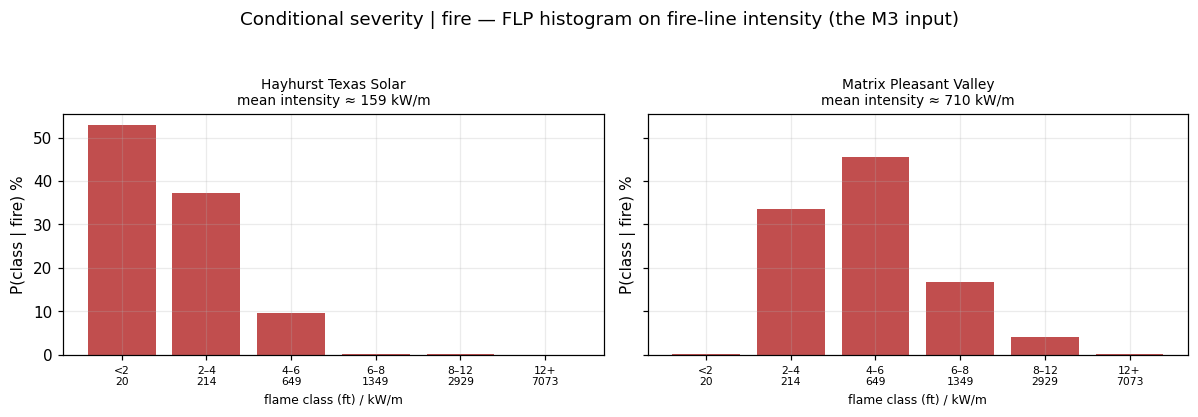

Hayhurst Texas Solar    : severity Σprob=1.000 (=1 ✓) · mean |fire = 159 kW/m · P(>4 ft|fire)=0.100
Matrix Pleasant Valley  : severity Σprob=1.000 (=1 ✓) · mean |fire = 710 kW/m · P(>4 ft|fire)=0.662


In [4]:
fig, axes = plt.subplots(1, len(ASSETS), figsize=(11, 3.6), sharey=True)
for ax, a in zip(np.atleast_1d(axes), ASSETS):
    a["mean_kwm"] = float(a["flp"] @ FIL_KWM)
    ax.bar(range(6), 100 * a["flp"], color="firebrick", alpha=0.8)
    ax.set_xticks(range(6)); ax.set_xticklabels([f"{FIL_FT[i]}\n{FIL_KWM[i]:.0f}" for i in range(6)], fontsize=7)
    ax.set_xlabel("flame class (ft) / kW/m", fontsize=8); ax.set_ylabel("P(class | fire) %")
    ax.set_title(f"{a['name']}\nmean intensity ≈ {a['mean_kwm']:.0f} kW/m", fontsize=9)
fig.suptitle("Conditional severity | fire — FLP histogram on fire-line intensity (the M3 input)", y=1.04)
fig.tight_layout(); plt.show()
for a in ASSETS:
    print(f"{a['name']:24s}: severity Σprob={a['flp'].sum():.3f} (=1 ✓) · mean |fire = {a['mean_kwm']:.0f} kW/m · "
          f"P(>4 ft|fire)={a['flp'][2:].sum():.3f}")

## 6 · Edge-rule sensitivity check (AW-21) — is the all-touched footprint mean a material lever?

Recompute the footprint mean of **BP** and **FLEP4 (=ΣFLP₃₋₆)** from the cached FSim 270 m rasters under
three boundary rules — **center-in**, **all-touched** (what we used), **area-weighted** (super-sampled
coverage fraction). If the spread is small, the rule is a second-order lever (AW-21) and `all_touched` stands.

In [5]:
def read_band(slug, name, scale):
    with rasterio.open(RAW_BASE / slug / f"fsim_{name}.tif") as ds:
        arr = ds.read(1).astype("float64")
        arr = np.where(arr < 0, np.nan, arr) * scale
        return arr, ds.transform, (ds.height, ds.width)


def threeway(value, geom, transform, shape, factor=8):
    center = rasterize([(geom, 1)], out_shape=shape, transform=transform, all_touched=False, dtype="uint8").astype(bool)
    touched = rasterize([(geom, 1)], out_shape=shape, transform=transform, all_touched=True, dtype="uint8").astype(bool)
    fine = rasterize([(geom, 1)], out_shape=(shape[0]*factor, shape[1]*factor),
                     transform=transform * rasterio.Affine.scale(1/factor), all_touched=False, dtype="uint8")
    frac = fine.reshape(shape[0], factor, shape[1], factor).mean(axis=(1, 3))
    fin = np.isfinite(value)
    def mean(mask):
        s = value[mask & fin]; return float(s.mean()) if s.size else np.nan
    w = frac * fin
    aw = float(np.nansum(np.where(fin, value, 0.0) * w) / w.sum()) if w.sum() > 0 else np.nan
    return {"center_in": mean(center), "all_touched": mean(touched), "area_weighted": aw,
            "n_center": int((center & fin).sum()), "n_touched": int((touched & fin).sum())}


rows = []
for a in ASSETS:
    bp_arr, tr, shp = read_band(a["slug"], "BP", 1/1e6)
    flep4_arr = sum(read_band(a["slug"], f"FLP{i}", 1/100)[0] for i in (3, 4, 5, 6))
    for q, arr in [("BP", bp_arr), ("FLEP4", flep4_arr)]:
        r = threeway(arr, a["footprint_geom"], tr, shp)
        spread = (max(r["center_in"], r["all_touched"], r["area_weighted"])
                  - min(r["center_in"], r["all_touched"], r["area_weighted"]))
        rng = abs(spread) / r["all_touched"] * 100 if r["all_touched"] else float("nan")
        rows.append({"asset": a["name"].split()[0], "qty": q, "center_in": round(r["center_in"], 4),
                     "all_touched": round(r["all_touched"], 4), "area_weighted": round(r["area_weighted"], 4),
                     "n_center→touched": f"{r['n_center']}→{r['n_touched']}", "spread_%_of_all_touched": round(rng, 1)})
sens = pd.DataFrame(rows).set_index(["asset", "qty"])
print("AW-21 edge-rule sensitivity (FSim 270 m):\n")
print(sens.to_string())
print("\nReading: Matrix (many pixels) → spread tiny; Hayhurst (few pixels) → larger %, but on a near-zero "
      "hazard → no decision changes. `all_touched` stands (AW-21); area-weighting deferred to the small-asset/"
      "high-fire trigger.")

AW-21 edge-rule sensitivity (FSim 270 m):

                center_in  all_touched  area_weighted n_center→touched  spread_%_of_all_touched
asset    qty                                                                                   
Hayhurst BP        0.0003       0.0004         0.0004             6→16                     10.8
         FLEP4     0.1333       0.1900         0.1391             6→16                     29.8
Matrix   BP        0.0431       0.0433         0.0431          100→140                      0.5
         FLEP4     0.6322       0.6242         0.6319          100→140                      1.3

Reading: Matrix (many pixels) → spread tiny; Hayhurst (few pixels) → larger %, but on a near-zero hazard → no decision changes. `all_touched` stands (AW-21); area-weighting deferred to the small-asset/high-fire trigger.


## 7 · Known-answer checks (basics spot-on)

In [6]:
for a in ASSETS:
    assert abs(a["flp"].sum() - 1.0) < 1e-9, "severity probs must sum to 1"
    assert abs(a["lambda_per_yr"] - (-math.log(1 - a["bp"]))) < 1e-12
    lam_ok = a["lambda_per_yr"] >= a["bp"]                    # λ = −ln(1−BP) ≥ BP always
    print(f"{a['name']:24s}: Σseverity=1 ✓ · λ≥BP ✓ ({lam_ok}) · λ={a['lambda_per_yr']:.5f} · "
          f"mean|fire={a['mean_kwm']:.0f} kW/m")
print("\n(No EAL cross-check here — that needs the M3 damage curve; M4 will verify λ·E[p·loss] vs the MC mean.)")

Hayhurst Texas Solar    : Σseverity=1 ✓ · λ≥BP ✓ (True) · λ=0.00037 · mean|fire=159 kW/m
Matrix Pleasant Valley  : Σseverity=1 ✓ · λ≥BP ✓ (True) · λ=0.04408 · mean|fire=710 kW/m

(No EAL cross-check here — that needs the M3 damage curve; M4 will verify λ·E[p·loss] vs the MC mean.)


## 8 · Emit per-asset catalog + manifest (the engine contract)

In [7]:
for a in ASSETS:
    sev = pd.DataFrame({"flame_class_ft": FIL_FT, "midpoint_ft": FIL_MID_FT,
                        "intensity_kwm": np.round(FIL_KWM, 1), "prob_given_fire": np.round(a["flp"], 6)})
    out_pq = DATA_DIR / f"{a['slug']}_wildfire_m1_catalog.parquet"
    sev.to_parquet(out_pq, index=False)
    manifest = {
        "catalog_id": f"{a['slug']}_wildfire_m1", "peril": "wildfire",
        "asset": {k: a[k] for k in ("slug", "name", "eia", "role", "lat", "lon", "dc_mw", "tiv_usd")},
        "coupling_type": "site_conditioned",
        "ontology": "per-asset hazard profile (BP + FLP1-6 over footprint); FSim pre-integrated (no discrete perimeter events in V1)",
        "backbone": "FSim FLP1-6 + BP (RDS-2016-0034-3, 270 m); WRC 30 m cross-check",
        "magnitude_metric": "fire-line intensity (kW/m) via Byram from FLP flame-length classes",
        "frequency_process": "poisson",
        "frequency_process_params": {"lambda_per_yr": round(a["lambda_per_yr"], 6), "fano_factor": 1.0,
                                      "derivation": "lambda = -ln(1-BP); BP = FSim annual burn probability"},
        "severity_kwm_distribution": [{"flame_class_ft": FIL_FT[i], "intensity_kwm": round(float(FIL_KWM[i]), 1),
                                       "prob_given_fire": round(float(a["flp"][i]), 6)} for i in range(6)],
        "conditional_mean_intensity_kwm": round(a["mean_kwm"], 1),
        "footprint": a["footprint_kind"], "edge_rule": "all_touched (AW-21; sensitivity-checked)",
        "spatial_resolution_m": 270, "tiv_usd": a["tiv_usd"],
        "caveats": ["fano=1 structural (FSim pre-integrated dispersion; no annual-count series to test)",
                    "stationary — lambda(t) deferred (AW-13)",
                    "severity = 6 discrete FLP classes; '12+ ft' open-ended tail coarse (EVT/continuous deferred)",
                    "270 m screening-grade — small footprints undersampled (AW-21)"],
        "sources": {"spine": "FSim Probabilistic Wildfire Risk (geoplatform ImageServers)",
                    "cross_check": "WRC 2.0 (30 m); Hydronos validated (02b)"},
        "provenance": {"built_by": "Notebooks/wildfire/m1_catalog/01_catalog", "from": "M0 candidate 02 (FSim) footprint profile"},
    }
    (DATA_DIR / f"{a['slug']}_wildfire_m1_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
    print(f"wrote {out_pq.relative_to(ROOT)} + manifest  ·  λ={a['lambda_per_yr']:.5f}/yr · mean|fire={a['mean_kwm']:.0f} kW/m")

print("\nM1 COMPLETE (both assets). The catalog declares: λ (Poisson, from BP) + a conditional kW/m severity "
      "distribution + the typed manifest — the handoff M2/M4 consume.")
print("Next → M2 (solar coupling): site-conditioned step — susceptibility, oozing/surrounding-fuel (AW-15), "
      "emit the (p_hit, conditional intensity) pair for the reused M3/M4 contract.")

wrote data/wildfire/hayhurst_texas_solar_wildfire_m1_catalog.parquet + manifest  ·  λ=0.00037/yr · mean|fire=159 kW/m
wrote data/wildfire/matrix_pleasant_valley_wildfire_m1_catalog.parquet + manifest  ·  λ=0.04408/yr · mean|fire=710 kW/m

M1 COMPLETE (both assets). The catalog declares: λ (Poisson, from BP) + a conditional kW/m severity distribution + the typed manifest — the handoff M2/M4 consume.
Next → M2 (solar coupling): site-conditioned step — susceptibility, oozing/surrounding-fuel (AW-15), emit the (p_hit, conditional intensity) pair for the reused M3/M4 contract.
